# 1 Preparación de los datos

## 1.1 Importar y examimar los datos

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

In [2]:
# Cargar datos
train = pd.read_csv('/datasets/gold_recovery_train.csv')
test  = pd.read_csv('/datasets/gold_recovery_test.csv')
full  = pd.read_csv('/datasets/gold_recovery_full.csv')

# Examinar
for name, df in [('TRAIN', train), ('TEST', test), ('FULL', full)]:
    print(f"=== {name} ===")
    print(f"Shape: {df.shape}")
    print(df.info())
    print(df.describe())
    print()

=== TRAIN ===
Shape: (16860, 87)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  object 
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                      

## 1.2 Verificar el cálculo de recuperación

La fórmula de recuperación es:

$$
recovery = \frac{C\times(F-T)}{F\times(C-T)} \times 100
$$


Donde:
* $C$ = concentración de Au en el concentrado (`rougher.output.concentrate_au`)
* $F$ = concentración de Au en la alimentación (`rougher.input.feed_au`)
* $T$ = concentración de Au en las colas (`rougher.output.tail_au`)

In [3]:
# Calcular recuperación manualmente
C = train['rougher.output.concentrate_au']
F = train['rougher.input.feed_au']
T = train['rougher.output.tail_au']

recovery_calc = (C * (F - T)) / (F * (C - T)) * 100

# Crear un DataFrame para alinear ambas series y eliminar nulos juntas
comparison = pd.DataFrame({
    'real': train['rougher.output.recovery'],
    'calc': recovery_calc
}).dropna()  # elimina filas donde CUALQUIERA de las dos sea NaN

eam = mean_absolute_error(comparison['real'], comparison['calc'])
print(f"EAM entre recuperación calculada y real: {eam:.6f}")

EAM entre recuperación calculada y real: 0.000000


## 1.3 Características no disponibles en el conjunto de prueba

In [4]:
# Columnas presentes en train pero no en test
missing_in_test = set(train.columns) - set(test.columns)
print(f"Características ausentes en test: {len(missing_in_test)}")
for col in sorted(missing_in_test):
    print(f"  {col} — dtype: {train[col].dtype}")

Características ausentes en test: 34
  final.output.concentrate_ag — dtype: float64
  final.output.concentrate_au — dtype: float64
  final.output.concentrate_pb — dtype: float64
  final.output.concentrate_sol — dtype: float64
  final.output.recovery — dtype: float64
  final.output.tail_ag — dtype: float64
  final.output.tail_au — dtype: float64
  final.output.tail_pb — dtype: float64
  final.output.tail_sol — dtype: float64
  primary_cleaner.output.concentrate_ag — dtype: float64
  primary_cleaner.output.concentrate_au — dtype: float64
  primary_cleaner.output.concentrate_pb — dtype: float64
  primary_cleaner.output.concentrate_sol — dtype: float64
  primary_cleaner.output.tail_ag — dtype: float64
  primary_cleaner.output.tail_au — dtype: float64
  primary_cleaner.output.tail_pb — dtype: float64
  primary_cleaner.output.tail_sol — dtype: float64
  rougher.calculation.au_pb_ratio — dtype: float64
  rougher.calculation.floatbank10_sulfate_to_au_feed — dtype: float64
  rougher.calculation

Estas columnas ausentes generalmente corresponden a variables objetivo (`rougher.output.recovery`, `final.output.recovery`) y parámetros calculados más tarde en el proceso.

## 1.4 Preprocesamiento de datos

In [5]:
# Revisar valores nulos
print("Nulos en train:", train.isna().sum().sum())
print("Nulos en test:", test.isna().sum().sum())

# Rellenar nulos con la mediana de cada columna
train = train.fillna(train.median(numeric_only=True))
test  = test.fillna(test.median(numeric_only=True))

print("\nNulos tras preprocesamiento:")
print("Train:", train.isna().sum().sum())
print("Test:", test.isna().sum().sum())

Nulos en train: 30320
Nulos en test: 2360

Nulos tras preprocesamiento:
Train: 0
Test: 0


Usamos la mediana en lugar de la media porque es más robusta ante valores atípicos, algo común en datos industriales.

# 2. Analisis de los datos

## 2.1 Concentración de metales por etapa de purificación

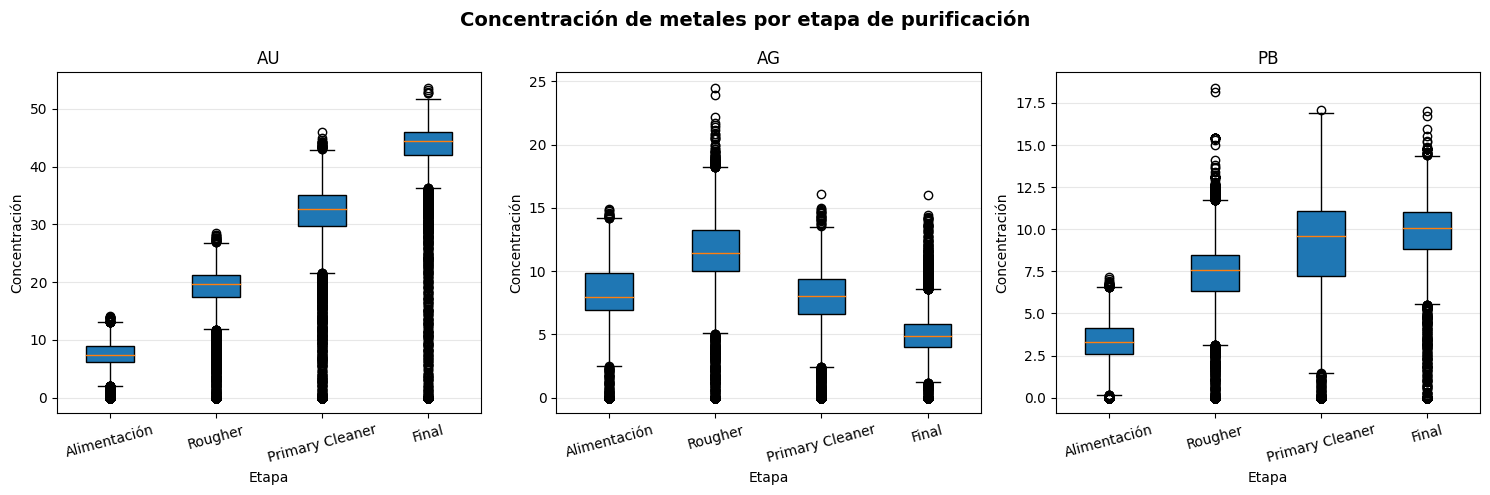

In [6]:
# Metales y etapas del proceso
metals = ['au', 'ag', 'pb']
stages = ['rougher.input', 'rougher.output', 'primary_cleaner.output', 'final.output']
stage_labels = ['Alimentación', 'Rougher', 'Primary Cleaner', 'Final']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Concentración de metales por etapa de purificación', fontsize=14, fontweight='bold')

for ax, metal in zip(axes, metals):
    concentrations = []
    for stage in stages:
        col = f'{stage}.feed_{metal}' if stage == 'rougher.input' else f'{stage}.concentrate_{metal}'
        if col in train.columns:
            concentrations.append(train[col].dropna())
        else:
            concentrations.append(pd.Series([np.nan]))
    
    ax.boxplot(concentrations, labels=stage_labels, patch_artist=True)
    ax.set_title(f'{metal.upper()}')
    ax.set_ylabel('Concentración')
    ax.set_xlabel('Etapa')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 2.2 Distribución del tamaño de partículas: train vs test

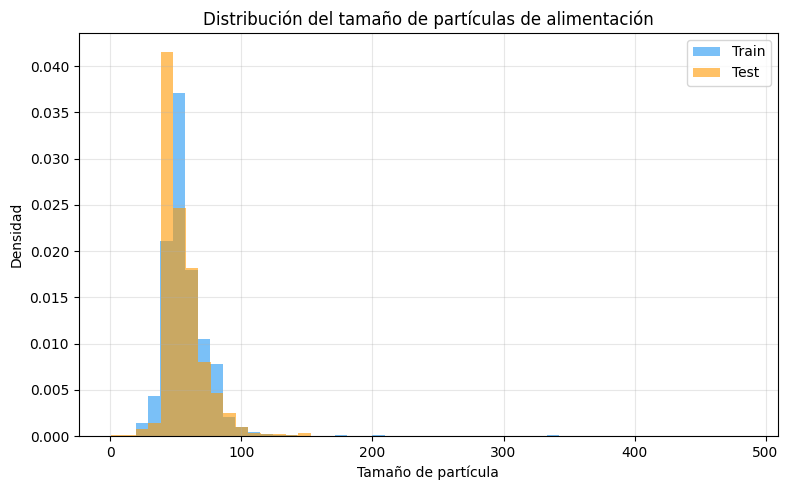

In [7]:
particle_col = 'rougher.input.feed_size'

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(train[particle_col].dropna(), bins=50, alpha=0.6, label='Train', color='#2196F3', density=True)
ax.hist(test[particle_col].dropna(),  bins=50, alpha=0.6, label='Test',  color='#FF9800', density=True)
ax.set_title('Distribución del tamaño de partículas de alimentación')
ax.set_xlabel('Tamaño de partícula')
ax.set_ylabel('Densidad')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.3 Concentraciones totales por etapa y detección de anomalías

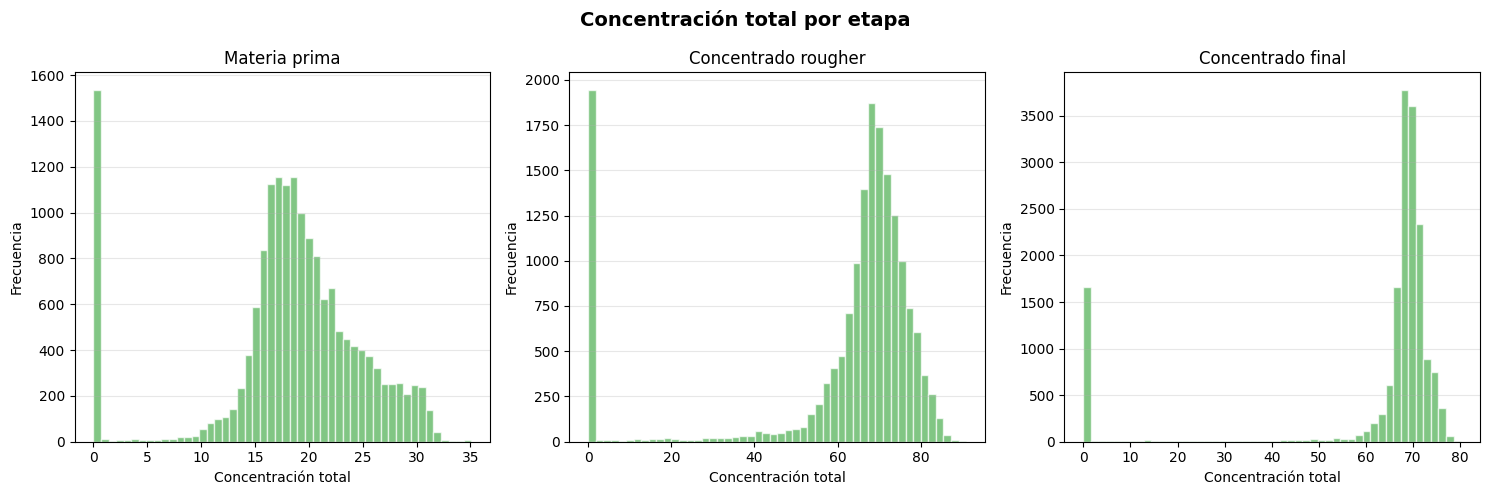

Materia prima: 1159 filas con concentración total = 0
Concentrado rougher: 1493 filas con concentración total = 0
Concentrado final: 1263 filas con concentración total = 0

Filas originales en train: 16860
Filas tras eliminar anomalías: 15178


In [8]:
# Columnas de concentración por etapa
stage_cols = {
    'Materia prima':        [c for c in train.columns if 'rougher.input.feed' in c and any(m in c for m in metals)],
    'Concentrado rougher':  [c for c in train.columns if 'rougher.output.concentrate' in c],
    'Concentrado final':    [c for c in train.columns if 'final.output.concentrate' in c],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Concentración total por etapa', fontsize=14, fontweight='bold')

for ax, (stage_name, cols) in zip(axes, stage_cols.items()):
    total = train[cols].sum(axis=1)
    ax.hist(total.dropna(), bins=50, color='#4CAF50', alpha=0.7, edgecolor='white')
    ax.set_title(stage_name)
    ax.set_xlabel('Concentración total')
    ax.set_ylabel('Frecuencia')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Detectar y eliminar anomalías (concentración total = 0)
for stage_name, cols in stage_cols.items():
    total = train[cols].sum(axis=1)
    anomalies = (total == 0).sum()
    print(f"{stage_name}: {anomalies} filas con concentración total = 0")

# Eliminar filas anómalas del train
mask_train = True
for cols in stage_cols.values():
    mask_train = mask_train & (train[cols].sum(axis=1) > 0)

train_clean = train[mask_train].reset_index(drop=True)
print(f"\nFilas originales en train: {len(train)}")
print(f"Filas tras eliminar anomalías: {len(train_clean)}")

In [9]:
# Fechas válidas del train_clean
valid_dates = set(train_clean['date'])

# Filtrar full con esas fechas
full_clean = full[full['date'].isin(valid_dates)].reset_index(drop=True)

# Filtrar test: fechas de test que NO están en train (test es la parte restante de full)
test_dates = set(test['date'])
valid_test_dates = test_dates  # test no tiene anomalías de concentración que eliminar directamente

test_clean = test.reset_index(drop=True)

print(f"Filas en train_clean: {len(train_clean)}")
print(f"Filas en full_clean:  {len(full_clean)}")
print(f"Filas en test_clean:  {len(test_clean)}")

Filas en train_clean: 15178
Filas en full_clean:  15178
Filas en test_clean:  5856


## 3.1 Función sMAPE

El sMAPE (error porcentual absoluto medio simétrico) se calcula así:

$$
sMAPE = \frac{1}{n} \sum_{i=1}^{n} \frac{|y_i - \hat{y}_i|}{(|y_i| + |\hat{y}_i|) / 2} \times 100\%
$$

In [10]:
def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100

El $sMAPE_{final}$ combina `rougher` y `final` con pesos:

$$
sMAPE\_final = 0.25 \times sMAPE_{rougher} + 0.75 \times sMAPE_{final}
$$

In [11]:
def final_smape(y_true_rougher, y_pred_rougher, y_true_final, y_pred_final):
    return 0.25 * smape(y_true_rougher, y_pred_rougher) + \
           0.75 * smape(y_true_final, y_pred_final)

## 3.2 Entrenar y evaluar modelos

Definimos features y targets:

In [12]:
# Features: solo columnas presentes en test
features = [col for col in test_clean.columns if col != 'date']

# Targets
target_rougher = 'rougher.output.recovery'
target_final   = 'final.output.recovery'

X_train         = train_clean[features]
y_train_rougher = train_clean[target_rougher]
y_train_final   = train_clean[target_final]

print(f"Features usadas: {len(features)}")
print(f"Shape X_train: {X_train.shape}")

Features usadas: 52
Shape X_train: (15178, 52)


### Prueba de sanidad

In [13]:
print("=== Prueba de Sanidad ===\n")
kf = KFold(n_splits=5, shuffle=True, random_state=12345)
sanity_scores = []

for train_idx, val_idx in kf.split(X_train):
    yr_tr  = y_train_rougher.iloc[train_idx]
    yf_tr  = y_train_final.iloc[train_idx]
    yr_val = y_train_rougher.iloc[val_idx]
    yf_val = y_train_final.iloc[val_idx]
    pred_rougher_sanity = np.full(len(yr_val), yr_tr.mean())
    pred_final_sanity   = np.full(len(yf_val), yf_tr.mean())
    sanity_scores.append(final_smape(yr_val, pred_rougher_sanity, yf_val, pred_final_sanity))

sanity_smape = np.mean(sanity_scores)
print(f"sMAPE baseline (predice la media): {sanity_smape:.4f}")

=== Prueba de Sanidad ===

sMAPE baseline (predice la media): 9.9939


Ahora entrenamos con validación cruzada usando sMAPE real:

In [14]:
def cross_val_smape(model, X, y_rougher, y_final, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=12345)
    scores = []
    for train_idx, val_idx in kf.split(X):
        X_tr,  X_val  = X.iloc[train_idx],        X.iloc[val_idx]
        yr_tr, yr_val = y_rougher.iloc[train_idx], y_rougher.iloc[val_idx]
        yf_tr, yf_val = y_final.iloc[train_idx],   y_final.iloc[val_idx]
        model.fit(X_tr, yr_tr)
        pred_rougher = model.predict(X_val)
        model.fit(X_tr, yf_tr)
        pred_final = model.predict(X_val)
        scores.append(final_smape(yr_val, pred_rougher, yf_val, pred_final))
    return np.mean(scores), np.std(scores)

models = {
    'Regresión Lineal':      LinearRegression(),
    'Random Forest (n=50)':  RandomForestRegressor(n_estimators=50,  random_state=12345),
    'Random Forest (n=100)': RandomForestRegressor(n_estimators=100, random_state=12345),
}


print("\n=== Validación cruzada (5 folds) ===\n")
results_cv = {}
for name, model in models.items():
    mean_score, std_score = cross_val_smape(model, X_train, y_train_rougher, y_train_final)
    results_cv[name] = mean_score
    print(f"{name}:")
    print(f"  sMAPE combinado: {mean_score:.4f} ± {std_score:.4f}")
    print()

best_name = min(results_cv, key=results_cv.get)
print(f"sMAPE baseline:              {sanity_smape:.4f}")
print(f"sMAPE {best_name}: {results_cv[best_name]:.4f}")
print()
if results_cv[best_name] < sanity_smape:
    print("✓ El modelo supera el baseline — prueba de sanidad APROBADA")
else:
    print("✗ El modelo NO supera el baseline — revisar pipeline")


print(f"\n=== Evaluación en Test ({best_name}) ===\n")
best_model = models[best_name]


=== Validación cruzada (5 folds) ===

Regresión Lineal:
  sMAPE combinado: 8.0869 ± 0.1580

Random Forest (n=50):
  sMAPE combinado: 5.3462 ± 0.0929

Random Forest (n=100):
  sMAPE combinado: 5.3008 ± 0.0986

sMAPE baseline:              9.9939
sMAPE Random Forest (n=100): 5.3008

✓ El modelo supera el baseline — prueba de sanidad APROBADA

=== Evaluación en Test (Random Forest (n=100)) ===



Luego evaluamos el mejor modelo en test usando `full_clean` para obtener los targets reales:

In [15]:
# Ordenar por fecha para alinear
full_test  = full[full['date'].isin(set(test_clean['date']))].sort_values('date').reset_index(drop=True)
test_clean = test_clean.sort_values('date').reset_index(drop=True)

y_test_rougher = full_test[target_rougher]
y_test_final   = full_test[target_final]

best_model.fit(X_train, y_train_rougher)
pred_rougher_test = best_model.predict(test_clean[features])

best_model.fit(X_train, y_train_final)
pred_final_test = best_model.predict(test_clean[features])

# Filtrar filas válidas (sin nulos en targets)
mask_valid = y_test_rougher.notna() & y_test_final.notna()
print(f"Filas válidas para evaluación: {mask_valid.sum()} de {len(mask_valid)}")

Filas válidas para evaluación: 5290 de 5856


In [16]:
smape_test = final_smape(
    y_test_rougher[mask_valid], pred_rougher_test[mask_valid],
    y_test_final[mask_valid],   pred_final_test[mask_valid]
)
print(f"sMAPE final en test: {smape_test:.4f}")

sMAPE final en test: 9.4258


In [17]:
print("=" * 55)
print("              RESUMEN FINAL DEL PROYECTO")
print("=" * 55)

print("\n VALIDACIÓN CRUZADA (5 folds):")
for name, score in results_cv.items():
    marker = " ✓ MEJOR" if name == best_name else ""
    print(f"  {name}: sMAPE = {score:.4f}{marker}")

print(f"\n MODELO SELECCIONADO: {best_name}")
print(f"   sMAPE en validación cruzada: {results_cv[best_name]:.4f}")
print(f"   sMAPE en test:               {smape_test:.4f}")

              RESUMEN FINAL DEL PROYECTO

 VALIDACIÓN CRUZADA (5 folds):
  Regresión Lineal: sMAPE = 8.0869
  Random Forest (n=50): sMAPE = 5.3462
  Random Forest (n=100): sMAPE = 5.3008 ✓ MEJOR

 MODELO SELECCIONADO: Random Forest (n=100)
   sMAPE en validación cruzada: 5.3008
   sMAPE en test:               9.4258


__HALLAZGOS PRINCIPALES:__

  1. EAM de recuperación = 0.0 → datos verificados y correctos
  2. 34 columnas ausentes en test (outputs y cálculos del proceso)
  3. $~9%$ de filas con concentración $total = 0$ eliminadas como anomalías
  4. Regresión Lineal $(sMAPE=8.09)$ superada ampliamente por Random Forest
  5. Random Forest n=100 es marginalmente mejor que $n=50$ ($5.30$ vs $5.35$)


__NOTA SOBRE EL RESULTADO EN TEST:__

El sMAPE en test $(9.43)$ es mayor que en validación $(5.30)$; esto sugiere ligero sobreajuste del `Random Forest`.
  
Una mejora posible sería ajustar hiperparámetros como `"max_depth"` o `"min_samples_split"` para regularizar el modelo.

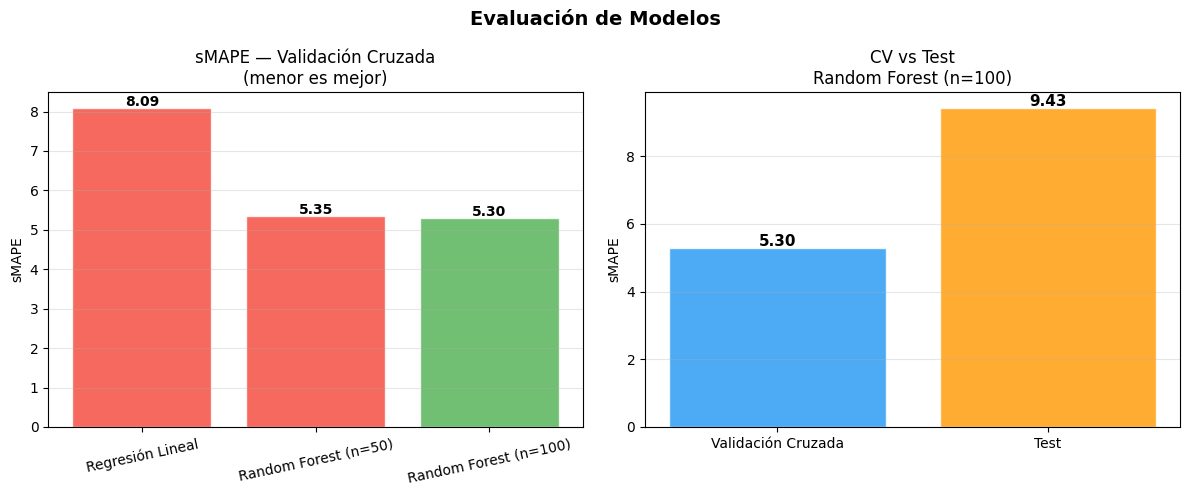

In [18]:
# Gráfico comparativo de modelos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Evaluación de Modelos', fontsize=14, fontweight='bold')

nombres = list(results_cv.keys())
scores_cv   = list(results_cv.values())
scores_test = [None, None, smape_test]  # solo el mejor tiene score en test
colors = ['#F44336' if n != best_name else '#4CAF50' for n in nombres]

# Panel 1 — Validación cruzada
ax = axes[0]
bars = ax.bar(nombres, scores_cv, color=colors, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, scores_cv):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('sMAPE — Validación Cruzada\n(menor es mejor)')
ax.set_ylabel('sMAPE')
ax.set_xticks(range(len(nombres)))
ax.set_xticklabels(nombres, rotation=12)
ax.grid(axis='y', alpha=0.3)

# Panel 2 — CV vs Test para el mejor modelo
ax2 = axes[1]
categorias = ['Validación Cruzada', 'Test']
valores     = [results_cv[best_name], smape_test]
bar_colors  = ['#2196F3', '#FF9800']
bars2 = ax2.bar(categorias, valores, color=bar_colors, alpha=0.8, edgecolor='white')
for bar, val in zip(bars2, valores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
ax2.set_title(f'CV vs Test\n{best_name}')
ax2.set_ylabel('sMAPE')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Conclusiones


## Preparación de datos

Se cargaron tres datasets (`"entrenamiento"`, `"prueba"` y `"fuente completa"`) con datos de
recuperación de oro en una planta de flotación. La verificación del cálculo de
recuperación arrojó un EAM de $0.0$, confirmando que los datos son correctos.

Se identificaron 34 características ausentes en el conjunto de prueba,
correspondientes a outputs de cada etapa del proceso (`rougher`, `primary cleaner`,
`final` y `secondary cleaner`) y cálculos derivados — variables que solo se conocen
después del proceso productivo.

Los valores nulos se rellenaron con la mediana de cada columna. Adicionalmente,
se detectaron y eliminaron filas con concentración total igual a cero en tres
etapas del proceso, lo que redujo el conjunto de entrenamiento de $16,860$ a
$15,178$ filas ($~10\%$ de anomalías eliminadas).


## Análisis de datos

La concentración de __Au__ aumenta progresivamente a lo largo de las etapas de
purificación, lo cual es consistente con el proceso esperado de flotación.

Las distribuciones del tamaño de partículas de alimentación son similares
entre `train` y `test`, lo que garantiza que la evaluación del modelo sea válida.


## Modelado

Se definió el $sMAPE$ final como métrica combinada:
  $$
  sMAPE\_final = 0.25 × sMAPE_{rougher} + 0.75 × sMAPE_{final}
  $$

Se entrenaron tres modelos con validación cruzada de 5 folds:

  | Modelo                | sMAPE (CV) |
  |-----------------------|------------|
  | Regresión Lineal      |   8.0869   |
  | Random Forest (n=50)  |   5.3462   |
  | Random Forest (n=100) |   5.3008 ✓ |

La prueba de sanidad confirmó que todos los modelos superan el baseline
(predicción constante igual a la media), validando que el pipeline es correcto.

El mejor modelo fue **Random Forest con 100 árboles** con un $sMAPE$ de $5.30$
en validación cruzada. Sin embargo, al evaluarlo en el conjunto de prueba
el $sMAPE$ subió a $9.43$, una diferencia de $~4$ puntos que indica sobreajuste
moderado.

Esto es esperable en datos industriales con alta variabilidad
temporal, donde el modelo entrenado en un período puede no generalizar
perfectamente a otro.